In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Rice_Citation_Request.txt
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (11154).jpg
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (8058).jpg
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5150).jpg
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (8267).jpg
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (8747).jpg
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (2970).jpg
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (10959).jpg
/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (4976).jpg
/kaggle/input

# 1. Load Libarires

In [2]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix


import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('dark_background')

# 2. Load Dataset

In [3]:
data = "/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset"

classes = [d for d in os.listdir(data) if os.path.isdir(os.path.join(data, d))]
print("Classes:",classes)

Classes: ['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala']


# 3. Visualizing the types of Rice 

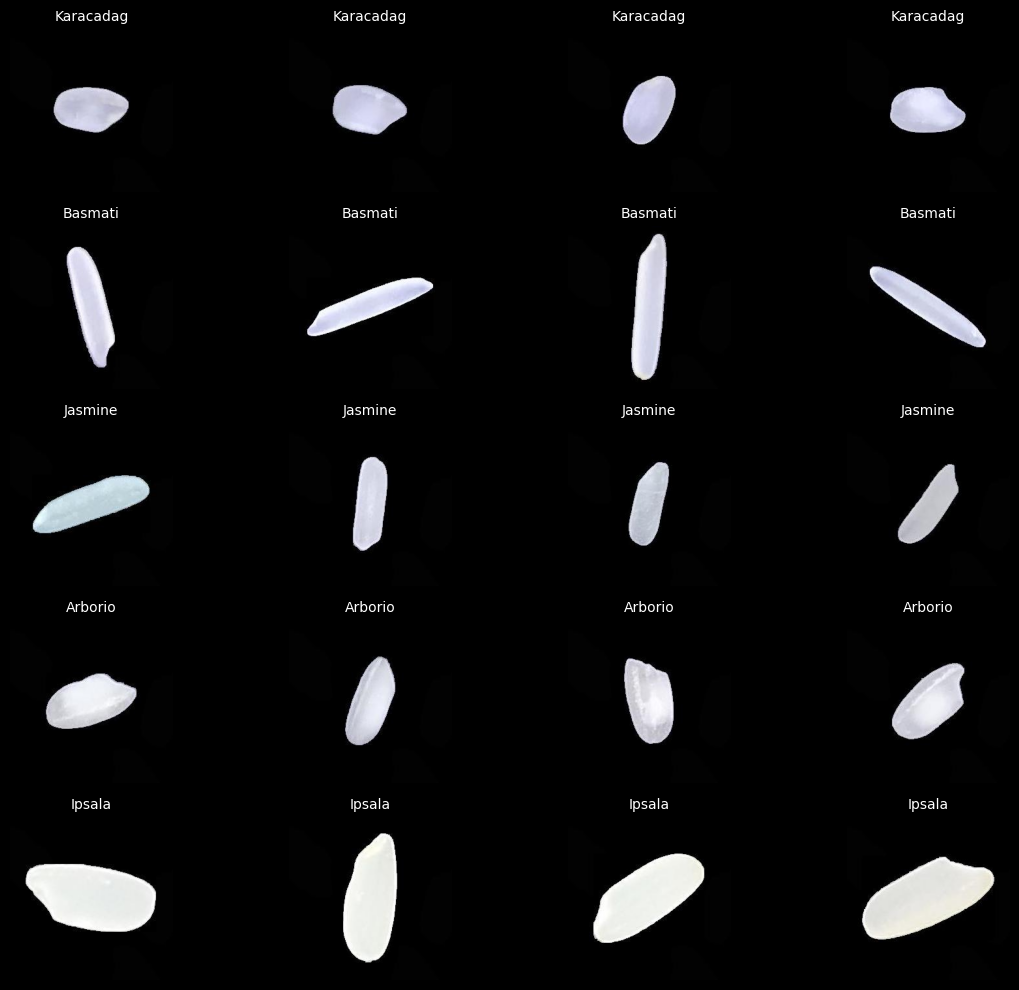

In [4]:
fig, axes = plt.subplots(len(classes), 4, figsize=(12,10))
for i,cls in enumerate(classes):
    cls_path = os.path.join(data, cls)
    sample_images = random.sample(os.listdir(cls_path), 4)
    for j, img_path in enumerate(sample_images):
        img_path = os.path.join(cls_path, img_path)
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        axes[i, j].set_title(cls,fontsize=10)

plt.tight_layout()
plt.show()


# 4.Create DataFrame

In [5]:
image_paths = []
labels = []

for class_name in sorted(os.listdir(data)):
    class_path = os.path.join(data, class_name)
    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(class_path, file_name))
                labels.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(df.head())
print("Total images:", len(df))
print(df["label"].value_counts())

                                          image_path    label
0  /kaggle/input/datasets/muratkokludataset/rice-...  Arborio
1  /kaggle/input/datasets/muratkokludataset/rice-...  Arborio
2  /kaggle/input/datasets/muratkokludataset/rice-...  Arborio
3  /kaggle/input/datasets/muratkokludataset/rice-...  Arborio
4  /kaggle/input/datasets/muratkokludataset/rice-...  Arborio
Total images: 75000
label
Arborio      15000
Basmati      15000
Ipsala       15000
Jasmine      15000
Karacadag    15000
Name: count, dtype: int64


# 5. Classes Distribution

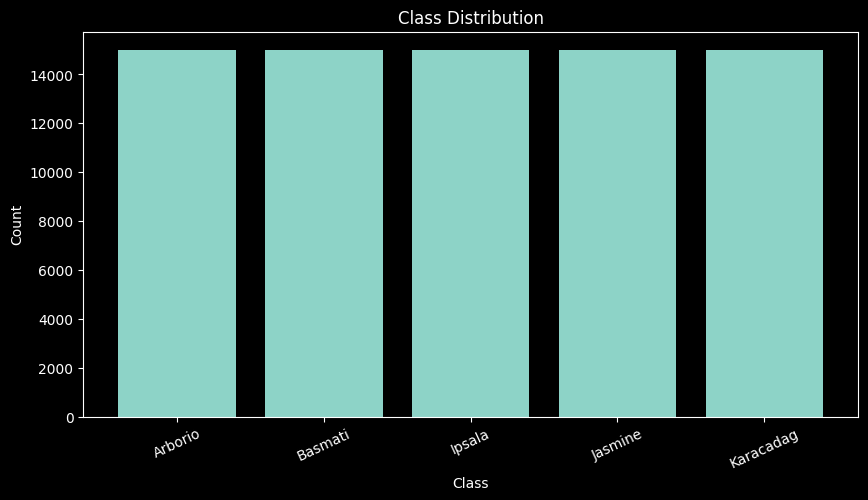

In [6]:
plt.figure(figsize=(10, 5))

order = df["label"].value_counts().index
counts = df["label"].value_counts().reindex(order)
plt.bar(order, counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks(rotation=25)
plt.show()

# 6. Splitting Data ( Train - Validation - Test )

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])

val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])


print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (52500, 2)
Validation: (11250, 2)
Test: (11250, 2)


In [8]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(data, validation_split=0.2, subset="training", seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical")


val_test_ds = image_dataset_from_directory(data, validation_split=0.2, subset="validation", seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical")


class_names = train_ds.class_names
print("Class names:", class_names)

# split 0.2 data equally into validation and test
val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2) 
val_ds = val_test_ds.skip(val_batches // 2)


print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 75000 files belonging to 5 classes.
Using 60000 files for training.


I0000 00:00:1786873046.575544      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786873046.579483      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 75000 files belonging to 5 classes.
Using 15000 files for validation.
Class names: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Train batches: 1875
Val batches: 235
Test batches: 234


# 7. Normalization for pixels

In [9]:
normalize = lambda x, y: (x / 255.0, y)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(normalize).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(normalize).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(normalize).cache().prefetch(AUTOTUNE)


# 8. Visualizing the types of Rice after normalization

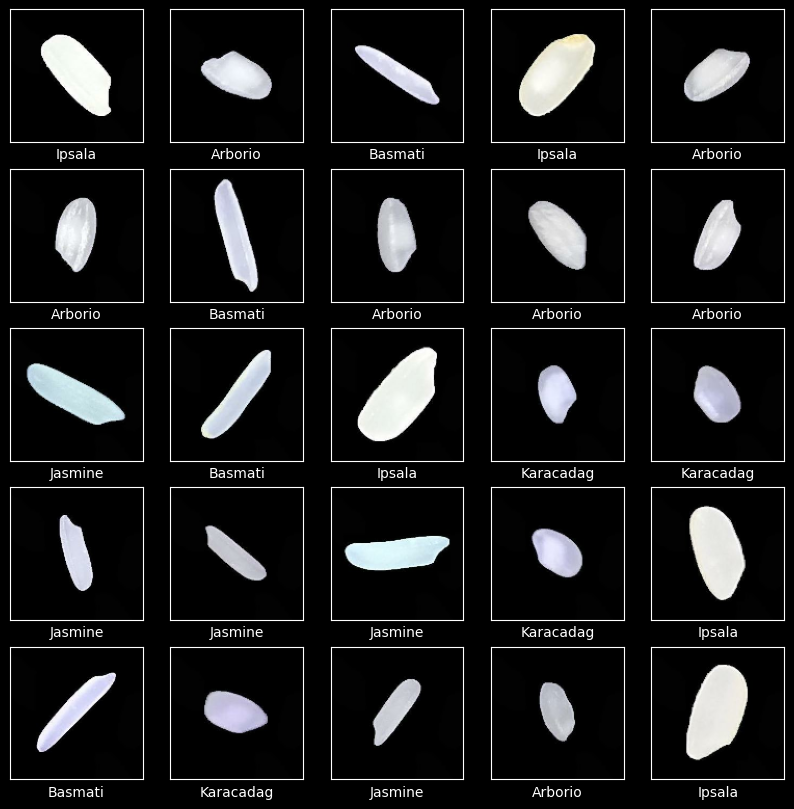

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].numpy())
        label_idx = int(tf.argmax(labels[i]))
        plt.xlabel(class_names[label_idx])


plt.show()

# 9. Building Model

In [11]:
num_classes = len(class_names)

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3), padding = 'same'))

model.add(layers.BatchNormalization())

model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(64, (3, 3), activation='relu', padding = 'same'))

model.add(layers.BatchNormalization())

model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(64, (3, 3), activation='relu', padding = 'same'))

model.add(layers.BatchNormalization())

model.add(layers.MaxPooling2D((2, 2)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,960 (222.50 KB)

 Trainable params: 56,640 (221.25 KB)

 Non-trainable params: 320 (1.25 KB)

In [13]:
model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(num_classes, activation = 'softmax'))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105,925 (4.22 MB)

 Trainable params: 1,105,605 (4.22 MB)

 Non-trainable params: 320 (1.25 KB)

# 10. Compiling

In [15]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 11. Callbacks

In [16]:
checkpoint_filepath = 'rice_cnn_model.h5'

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_delta=1e-4, mode='min', verbose=1)

stop_alg = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)


model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_accuracy', mode='max', save_best_only=True)


# 11. Training

In [17]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=[stop_alg, reduce_lr, model_checkpoint])


Epoch 1/5
   6/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.2368 - loss: 4.9902 

I0000 00:00:1786873076.237367      80 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8158 - loss: 0.4802

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 183s 93ms/step - accuracy: 0.8766 - loss: 0.2955 - val_accuracy: 0.9472 - val_loss: 0.2049 - learning_rate: 0.0010
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9409 - loss: 0.1604 - val_accuracy: 0.9444 - val_loss: 0.2279 - learning_rate: 0.0010
Epoch 3/5
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9512 - loss: 0.1376
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9532 - loss: 0.1316 - val_accuracy: 0.9316 - val_loss: 0.2338 - learning_rate: 0.0010
Epoch 4/5
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9708 - loss: 0.0858

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9750 - loss: 0.0798 - val_accuracy: 0.9866 - val_loss: 0.0485 - learning_rate: 5.0000e-04
Epoch 5/5
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9784 - loss: 0.0748

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9806 - loss: 0.0664 - val_accuracy: 0.9955 - val_loss: 0.0178 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 5.


# Save Model

In [18]:
model.save('rice_cnn_final.keras')

# 12. Visualizing Model Accuracy and Loss

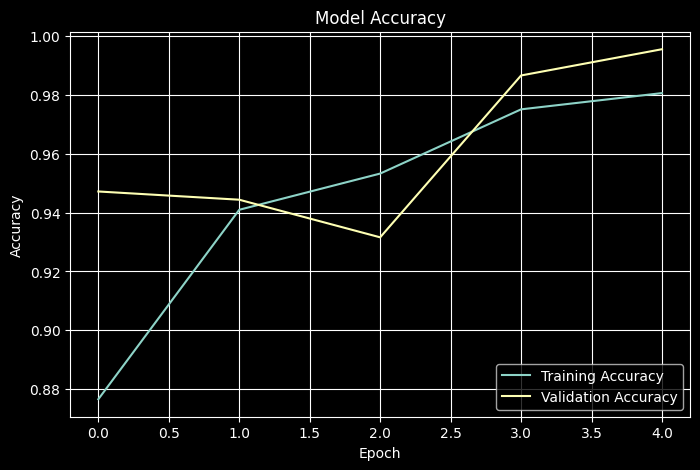

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(loc='lower right')
plt.grid()
plt.show()

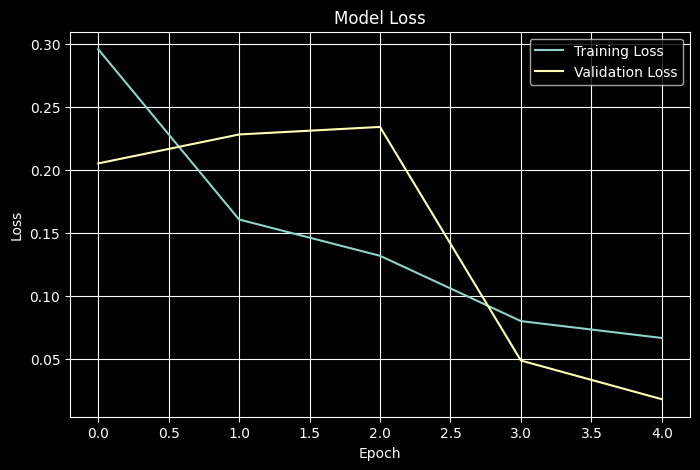

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(loc='upper right')
plt.grid()
plt.show()

              precision    recall  f1-score   support

     Arborio       1.00      0.99      0.99      1480
     Basmati       0.99      1.00      1.00      1545
      Ipsala       1.00      1.00      1.00      1430
     Jasmine       0.99      0.99      0.99      1521
   Karacadag       0.99      1.00      1.00      1512

    accuracy                           1.00      7488
   macro avg       1.00      1.00      1.00      7488
weighted avg       1.00      1.00      1.00      7488



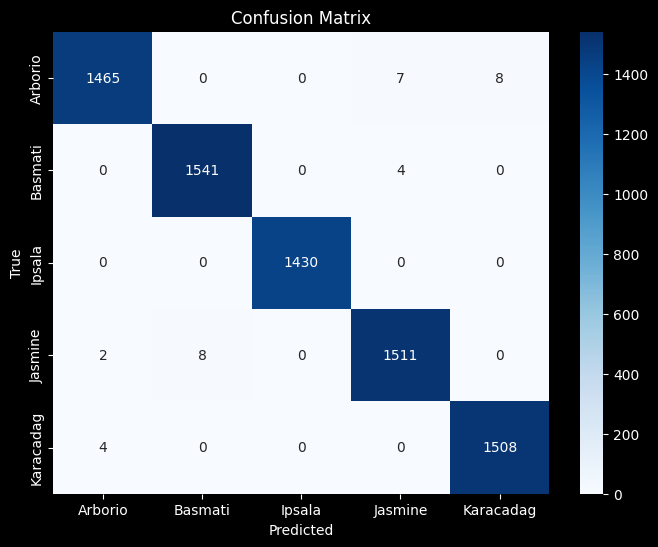

In [21]:
y_true = []
y_pred = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)


plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")


plt.show()

In [22]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print("Model Accuracy", test_acc)

234/234 - 1s - 5ms/step - accuracy: 0.9956 - loss: 0.0177
Model Accuracy 0.9955929517745972


# 13. Prediction in new data

Class mapping: {0: 'Arborio', 1: 'Basmati', 2: 'Ipsala', 3: 'Jasmine', 4: 'Karacadag'}
Probabilities: [0.000000e+00 1.000000e+00 0.000000e+00 6.881615e-20 0.000000e+00]
Predicted: Basmati


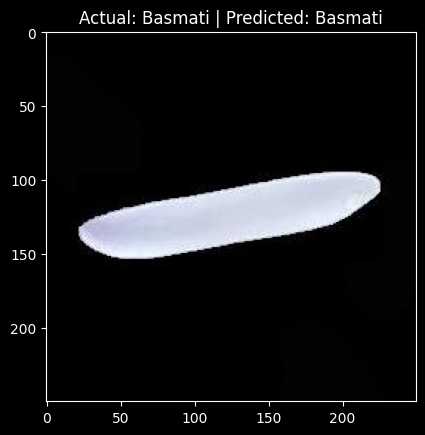

In [23]:
val_class = random.choice(classes) # Pick a random image from validation set
val_class_path = os.path.join(data, val_class)
random_image = random.choice(os.listdir(val_class_path))
img_path = os.path.join(val_class_path, random_image)


img = image.load_img(img_path, target_size=IMG_SIZE) # Load image
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)


# Predict
prediction = model.predict(img_array, verbose=0)
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]




print("Class mapping:", {i: c for i, c in enumerate(class_names)})
print("Probabilities:", prediction[0])
print("Predicted:", predicted_class)


plt.imshow(plt.imread(img_path))
plt.axis("on")
plt.title(f"Actual: {val_class} | Predicted: {predicted_class}")
plt.show()